In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)
print("Target names:", data.target_names)

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [ ]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [ ]:
results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, y_pred_lr),
    "Random Forest": evaluate_model(y_test, y_pred_rf),
    "Gradient Boosting": evaluate_model(y_test, y_pred_gb)
}).T

print("Model Comparison:")
print(results)

Model Comparison:
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.982456   0.986111  0.986111  0.986111
Random Forest        0.956140   0.958904  0.972222  0.965517
Gradient Boosting    0.956140   0.946667  0.986111  0.965986


In [ ]:
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
Mean CV accuracy: 0.9560937742586555


In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Optimized Random Forest Report:")
print(classification_report(y_test, y_pred_best_rf))

Optimized Random Forest Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
final_results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, y_pred_lr),
    "Random Forest": evaluate_model(y_test, y_pred_rf),
    "Gradient Boosting": evaluate_model(y_test, y_pred_gb),
    "Optimized Random Forest": evaluate_model(y_test, y_pred_best_rf)
}).T

print("Final Results:")
print(final_results)

Final Results:
                         Accuracy  Precision    Recall  F1 Score
Logistic Regression      0.982456   0.986111  0.986111  0.986111
Random Forest            0.956140   0.958904  0.972222  0.965517
Gradient Boosting        0.956140   0.946667  0.986111  0.965986
Optimized Random Forest  0.956140   0.958904  0.972222  0.965517


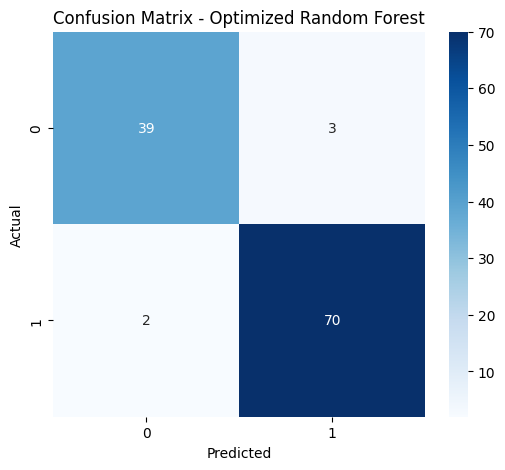

In [ ]:
cm = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

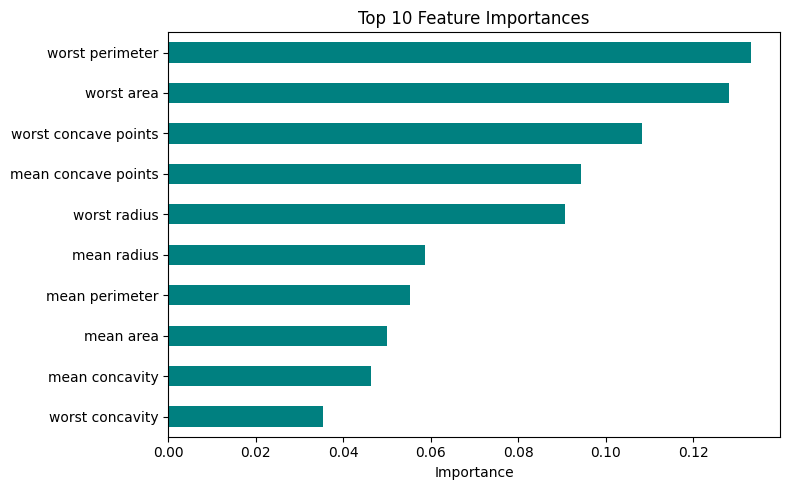

In [ ]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = final_results["F1 Score"].idxmax()
print("Best model based on F1 Score:", best_model_name)
print("Best F1 Score:", final_results.loc[best_model_name, "F1 Score"])

Best model based on F1 Score: Logistic Regression
Best F1 Score: 0.9861111111111112
